# Integration by Parts: 3RScan & 3DSSG Pipeline


In [1]:
import os
import sys
from pathlib import Path

sys.path.append(os.path.abspath("."))

from mtp_pipeline.config import ProjectPaths

# Static 3DSSG protocol: the official OCRL 160-object / 26-relation split.
# Temporal and dynamic losses are intentionally disabled below because 3DSSG
# annotations are static scan groups, not moving-object video tracklets.
EXPERIMENT_MODE = "static"
SEED = 42

paths = ProjectPaths()
run_output_root = paths.output_root / "official_static_pretrained_pointnet_run"
official_split_dir = Path(r"D:\MTP_Project\MTP_Pipeline_3RScan\official_splits")
train_scans_file = official_split_dir / "train_scans.txt"
val_scans_file = official_split_dir / "validation_scans.txt"

text_output_dir = paths.reference_root / "3rscan_text_embeddings"
lidar_output_dir = paths.reference_root / "3rscan_pointnet_pretrained_tokens"
rgb_output_dir = paths.reference_root / "3rscan_rgb_temporal"
database_output = paths.output_root / "3rscan_official_static_database_v2"
pointnet_checkpoint = Path(r"D:\MTP_Project\MTP_Pipeline_3RScan\reference\pretrained\obj_enc.pth")

print(f"Experiment mode: {EXPERIMENT_MODE}")
print(f"Seed: {SEED}")
print(f"Pretrained PointNet checkpoint: {pointnet_checkpoint}")
print(f"Run outputs: {run_output_root}")
print(f"Database: {database_output}")


Experiment mode: static
Seed: 42
Pretrained PointNet checkpoint: D:\MTP_Project\MTP_Pipeline_3RScan\reference\pretrained\obj_enc.pth
Run outputs: D:\MTP_Project\MTP_Pipeline_3RScan\pipeline_outputs\official_static_pretrained_pointnet_run
Database: D:\MTP_Project\MTP_Pipeline_3RScan\pipeline_outputs\3rscan_official_static_database_v2


In [4]:
#Text Embeddings
from mtp_pipeline.prepare_3rscan_text import prepare_3rscan_text_embeddings

objects_json = Path(r"D:\MTP_Project\3DSSG\objects.json")


prepare_3rscan_text_embeddings(
    objects_json=objects_json,
    output_dir=text_output_dir,
    model_name="openai/clip-vit-base-patch32",
    device="cuda"
)

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

[transformers] CLIPTextModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                                            | Status     |  | 
---------------------------------------------------------------+------------+--+-
vision_model.post_layernorm.weight                             | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.out_proj.weight | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.mlp.fc2.weight            | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.layer_norm2.weight        | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.mlp.fc2.bias              | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.out_proj.bias   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.layer_norm1.bias          | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.mlp.fc1.weight            | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.q_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.l

In [5]:
# LiDAR embeddings: official OCRL pretrained PointNet (XYZ + RGB + normals).
# This is resumable. Do not use the old 3rscan_lidar_tokens directory.
from mtp_pipeline.prepare_3rscan_lidar import prepare_3rscan_lidar_tokens

scan_dir = Path(r"D:\MTP_Project\3RScan")
objects_json = Path(r"D:\MTP_Project\3DSSG\objects.json")

prepare_3rscan_lidar_tokens(
    scan_dir=scan_dir,
    objects_json=objects_json,
    output_dir=lidar_output_dir,
    checkpoint=pointnet_checkpoint,
    official_subset_dir=official_split_dir,
    device="cuda",
)


Extracting official pretrained PointNet tokens: 100%|████████████████████████████| 1335/1335 [1:00:14<00:00,  2.71s/it]

Processed 34833 official objects; saved 34249; skipped 52.


In [6]:
# RGB crops are extracted from the available registered scan frames.
# The static database builder below selects exactly one largest-visible crop per object.
from mtp_pipeline.prepare_3rscan_rgb import prepare_3rscan_rgb_tokens

prepare_3rscan_rgb_tokens(
    scan_dir=scan_dir,
    objects_json=objects_json,
    output_dir=rgb_output_dir,
    model_name="openai/clip-vit-base-patch32",
    device="cuda",
)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] CLIPVisionModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                                          | Status     |  | 
-------------------------------------------------------------+------------+--+-
text_model.encoder.layers.{0...11}.layer_norm1.weight        | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.v_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.k_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm2.bias          | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.k_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc2.bias              | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.out_proj.bias   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc2.weight            | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm1.bias          | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_at

## Building the Training Database
Merging the extracted modalities and link them with the 3DSSG ground truth relationship labels.

In [7]:
relationships_json = Path(r"D:\MTP_Project\3DSSG\relationships.json")
objects_json = Path(r"D:\MTP_Project\3DSSG\objects.json")

from mtp_pipeline.build_3rscan_static_database import build_3rscan_static_scene_database

saved = build_3rscan_static_scene_database(
    objects_json=objects_json,
    relationships_json=relationships_json,
    official_subset_dir=official_split_dir,
    lidar_dir=lidar_output_dir,
    text_dir=text_output_dir,
    rgb_dir=rgb_output_dir,
    output_dir=database_output,
)
print(f"Built corrected official static database with {saved} annotation entries.")


Building official static 3DSSG database: 100%|█████████████████████████████████████| 4400/4400 [03:20<00:00, 22.00it/s]

Saved 4400/4400 scenes; skipped 0 with no usable object embeddings.
Built corrected official static database with 4400 annotation entries.


\n## Training\n\nFor the base-paper comparison, use static mode. The official split has 1,178 training and 157 validation reference scans; their annotation versions expand to 3,852 training and 548 validation scan_split examples. This path uses the exact 160 object classes and 26 multi-label positive relations. Category-name text embeddings remain contrastive supervision but are excluded from the SGCls graph input, so they cannot reveal the target class. The temporal path remains a separate extension experiment.\n\n

In [ ]:
import argparse
from mtp_pipeline.train import train

args = argparse.Namespace(
    reference_root=paths.reference_root,
    output_root=run_output_root,
    database=database_output,
    mode="static",
    train_scans=train_scans_file,
    val_scans=val_scans_file,
    split_seed=SEED,
    seed=SEED,
    epochs=50,
    max_scenes=None,
    max_frames=None,
    learning_rate=1e-4,
    resume_checkpoint=None,
    # None keeps every ordered pair, matching the official candidate-pair protocol.
    negative_ratio=None,
    # These are explicitly inactive for the static 3DSSG protocol.
    lambda_temporal=0.0,
    lambda_temporal_part=0.0,
    lambda_node=1.0,
    lambda_edge=1.0,
    lambda_dynamic=0.0,
    grad_clip=1.0,
    device="cuda",
    shuffle=True,
    num_parts=7,
    ablation="none",
)

checkpoint_path = train(args)
print(f"Training finished. Checkpoint saved to: {checkpoint_path}")


Label protocol: OCRL-3DSSG official subset: 160 objects, 26 positive multi-label relations
Using official 3DSSG split.
Training on 3852 scenes (Validation reserved: 548)
Computing Alpha class weights to balance rare 3DSSG relationships...


Epoch 1/50:  26%|▎| 1012/3852 [01:34<05:00,  9.45it/s, total=7.55, representation=5.12, temporal=0, temporal_part=0, no

## Plotting Hestory

## Resume Interrupted Static Training

For an interrupted run, restart the kernel, run the first configuration cell, then run the following cell. Do not rerun modality extraction or database construction.


In [2]:
import argparse
import importlib
import re
from pathlib import Path
import mtp_pipeline.train as train_module

# Reload the corrected resume logic after starting a fresh kernel.
importlib.reload(train_module)

checkpoint_dir = run_output_root / "checkpoints"
completed = list(checkpoint_dir.glob("integration_by_parts_3rscan_epoch_*.pt"))
assert completed, "No completed checkpoint was found."
resume_checkpoint = max(
    completed,
    key=lambda path: int(re.search(r"epoch_(\d+)$", path.stem).group(1)),
)
print(f"Resuming from: {resume_checkpoint.name}")

args = argparse.Namespace(
    reference_root=paths.reference_root,
    output_root=run_output_root,
    database=database_output,
    mode="static",
    train_scans=train_scans_file,
    val_scans=val_scans_file,
    split_seed=SEED,
    seed=SEED,
    # This is the total target epoch count, not 50 additional epochs.
    epochs=50,
    max_scenes=None,
    max_frames=None,
    learning_rate=1e-4,
    resume_checkpoint=resume_checkpoint,
    negative_ratio=None,
    lambda_temporal=0.0,
    lambda_temporal_part=0.0,
    lambda_node=1.0,
    lambda_edge=1.0,
    lambda_dynamic=0.0,
    grad_clip=1.0,
    device="cuda",
    shuffle=True,
    num_parts=7,
    ablation="none",
)

checkpoint_path = train_module.train(args)
print(f"Training finished. Final checkpoint: {checkpoint_path}")


Resuming from: integration_by_parts_3rscan_epoch_50.pt
Label protocol: OCRL-3DSSG official subset: 160 objects, 26 positive multi-label relations
Using official 3DSSG split.
Training on 3852 scenes (Validation reserved: 548)
Computing Alpha class weights to balance rare 3DSSG relationships...
Warm-starting from checkpoint: D:\MTP_Project\MTP_Pipeline_3RScan\pipeline_outputs\official_static_pretrained_pointnet_run\checkpoints\integration_by_parts_3rscan_epoch_50.pt
Checkpoint already contains 50 epochs; target is 50. Nothing to resume.
Training finished. Final checkpoint: D:\MTP_Project\MTP_Pipeline_3RScan\pipeline_outputs\official_static_pretrained_pointnet_run\checkpoints\integration_by_parts_3rscan_epoch_50.pt


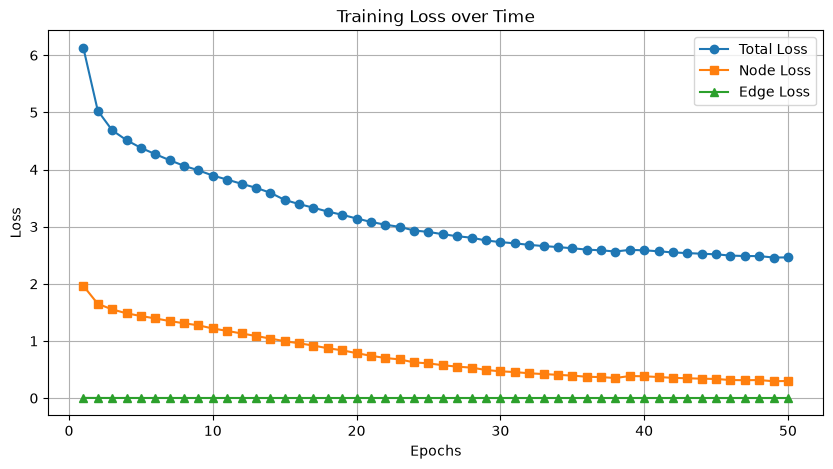

In [3]:
import json
import matplotlib.pyplot as plt

history_file = run_output_root / "training_history_3rscan.json"
with open(history_file, 'r') as f:
    history = json.load(f)

epochs = [x['epoch'] for x in history]
total_loss = [x['total'] for x in history]
node_loss = [x['node'] for x in history]
edge_loss = [x['edge'] for x in history]

plt.figure(figsize=(10, 5))
plt.plot(epochs, total_loss, label='Total Loss', marker='o')
plt.plot(epochs, node_loss, label='Node Loss', marker='s')
plt.plot(epochs, edge_loss, label='Edge Loss', marker='^')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training Loss over Time')
plt.legend()
plt.grid(True)
plt.show()

## Evaluating Base-Paper Metrics

This evaluation now reports base-paper-style sections:

- `base_paper_table_2`: Object R@1/R@5, Predicate R@1/R@3, Triplet R@50/R@100, plus mR variants.
- `base_paper_table_3`: SGCls and PredCls R@20/R@50/R@100 with and without graph constraints.
- `base_paper_table_10_mean_recall`: SGCls and PredCls mR@20/mR@50/mR@100.


In [4]:

from mtp_pipeline.evaluate_3dssg import evaluate_model

eval_args = argparse.Namespace(
    checkpoint=checkpoint_path,
    reference_root=paths.reference_root,
    output_root=run_output_root,
    database=database_output,
    mode=EXPERIMENT_MODE,
    train_scans=train_scans_file,
    val_scans=val_scans_file,
    split_seed=42,
    device="cuda",
)

evaluate_model(eval_args)


Protocol: OCRL-3DSSG official subset: 160 objects, 26 positive multi-label relations
Evaluating 548 official validation scenes on cuda.


Evaluating official OCRL 3DSSG protocol: 100%|███████████████████████████████████████| 548/548 [23:10<00:00,  2.54s/it]


--- Official OCRL/3DSSG Protocol Results (percent) ---
{
    "protocol": "OCRL-3DSSG official subset: 160 objects, 26 positive multi-label relations",
    "object_classes": 160,
    "positive_relation_classes": 26,
    "evaluated_scenes": 548,
    "base_paper_table_2": {
        "Object": {
            "R@1": 51.43,
            "R@5": 71.0,
            "mR@1": 15.4,
            "mR@5": 32.72
        },
        "Predicate": {
            "R@1": 83.76,
            "R@3": 93.25,
            "mR@1": 36.42,
            "mR@3": 57.99
        },
        "Triplet": {
            "R@50": 84.64,
            "R@100": 86.46,
            "mR@50": 43.05,
            "mR@100": 53.14
        }
    },
    "base_paper_table_3": {
        "SGCls": {
            "with_graph_constraints": {
                "R@20": 25.17,
                "R@50": 26.53,
                "R@100": 26.56
            },
            "without_graph_constraints": {
                "R@20": 26.33,
                "R@50": 30.13,
     